In [1]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import seaborn as sns
import jax.random as random
import jax.numpy as jnp
import numpy as np
import optax
import os
from dataclasses import dataclass
from typing import List, Optional, Dict, Any, Tuple
import sys
import importlib.util
import re

from shearnet.core.dataset import generate_dataset, split_combined_images
from shearnet.config.config_handler import Config

from flax.training import checkpoints, train_state
from shearnet.utils.metrics import eval_model, eval_ngmix, remove_nan_preds_multi

from shearnet.utils.plot_helpers import (
    plot_residuals, 
    plot_true_vs_predicted, 
    animate_model_epochs
)

from shearnet.utils.notebook_output_system import (
    log_print, save_plot, log_array_stats, experiment_section, get_output_manager
)

In [2]:
@dataclass
class ModelConfig:
    """Configuration for a ShearNet model to compare"""
    name: str  # Display name for plots
    model_dir_prefix: str  # Directory prefix to search for
    color: str  # Color for plots
    marker: str = 'o'  # Marker style for scatter plots
    
    def __post_init__(self):
        """Initialize configuration containers"""
        self.training_config = None
        self.test_config = None

In [3]:
# Define the models you want to compare
model_configs = [
    ModelConfig(
        name="second_validation_test_COSMOS",
        model_dir_prefix="second_validation_test_COSMOS",
        color="blue", 
        marker="s"
    ),
    ModelConfig(
        name="first_validation_test_sbpsf",
        model_dir_prefix="first_validation_test_sbpsf",
        color="green", 
        marker="s"
    ),
    # ModelConfig(
    #     name="Second Transformer Detection",
    #     model_dir_prefix="second_validation_transformer",
    #     color="green", 
    #     marker="s"
    # ),
    # Add more models here...
]

DEBUG: Current working directory: /home/adfield/ShearNet/notebooks
DEBUG: Found 'notebooks' in current path
DEBUG: Attempting to create directory: /home/adfield/ShearNet/notebooks/out
DEBUG: Directory created/exists: /home/adfield/ShearNet/notebooks/out
DEBUG: Directory is writable: True
DEBUG: Appended to existing output file: /home/adfield/ShearNet/notebooks/out/out.md
ShearNet Output Manager initialized:
  Output directory: /home/adfield/ShearNet/notebooks/out
  Output file: /home/adfield/ShearNet/notebooks/out/out.md
  Directory exists: True
  Can write to directory: True
second_validation_test_COSMOS training stats:
  Final training loss: 0.001223
  Final validation loss: 0.022214
  Best validation loss: 0.012738 at epoch 10
  Total epochs: 60
first_validation_test_sbpsf training stats:
  Final training loss: 0.001297
  Final validation loss: 0.022267
  Best validation loss: 0.012641 at epoch 11
  Total epochs: 61
DEBUG: Attempting to save plot to: /home/adfield/ShearNet/notebooks

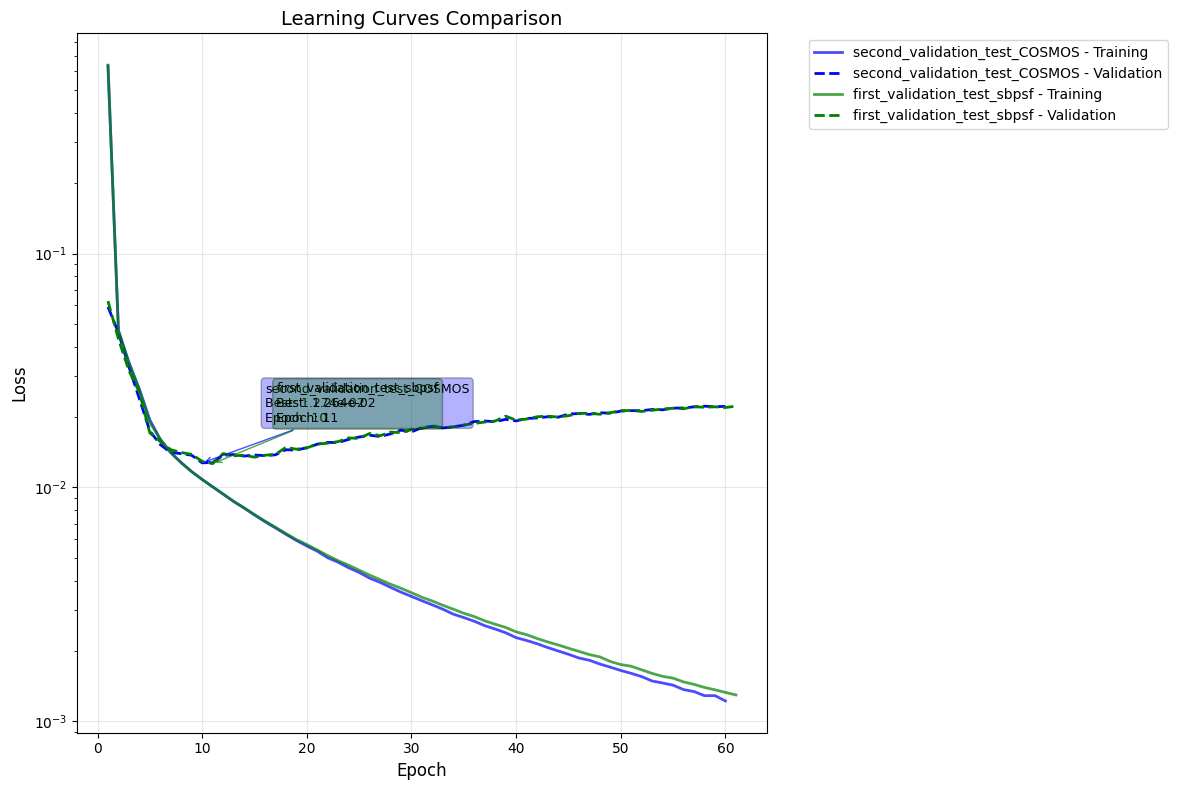

In [4]:
base_data_path = os.getenv('SHEARNET_DATA_PATH', os.path.abspath('.'))
    
plt.figure(figsize=(12, 8))

for config in model_configs:
    # Load loss data for this model
    loss_file = os.path.join(base_data_path, "plots", config.model_dir_prefix, f"{config.model_dir_prefix}_loss.npz")
    
    if os.path.exists(loss_file):
        loss = np.load(loss_file)
        train_loss = loss['train_loss']
        val_loss = loss['val_loss']
        
        epochs = np.arange(1, len(train_loss) + 1)
        
        # Plot with model-specific colors
        plt.plot(epochs, train_loss, color=config.color, linestyle='-', 
                label=f'{config.name} - Training', linewidth=2, alpha=0.7)
        plt.plot(epochs, val_loss, color=config.color, linestyle='--', 
                label=f'{config.name} - Validation', linewidth=2)
        
        # Add annotations for best validation loss
        best_val_epoch = np.argmin(val_loss) + 1
        best_val_loss = np.min(val_loss)
        plt.annotate(f'{config.name}\nBest: {best_val_loss:.3e}\nEpoch: {best_val_epoch}',
                    xy=(best_val_epoch, best_val_loss), 
                    xytext=(best_val_epoch + len(epochs)*0.1, best_val_loss * 1.5),
                    arrowprops=dict(arrowstyle='->', color=config.color, alpha=0.7),
                    fontsize=9,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor=config.color, alpha=0.3))
        
        # Log statistics
        log_print(f"{config.name} training stats:")
        log_print(f"  Final training loss: {train_loss[-1]:.6f}")
        log_print(f"  Final validation loss: {val_loss[-1]:.6f}") 
        log_print(f"  Best validation loss: {best_val_loss:.6f} at epoch {best_val_epoch}")
        log_print(f"  Total epochs: {len(train_loss)}")
    else:
        log_print(f"Warning: Loss file not found for {config.name}: {loss_file}")

plt.yscale("log")
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Learning Curves Comparison', fontsize=14)
plt.legend(fontsize=10, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

save_plot("learning_curves_comparison.png")
plt.show()